## IMPORT LIBRARIES

In [1]:
## Import Libraries

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Load DATASET

In [2]:
## Load Dataset

df = pd.read_csv("car_price_prediction.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [5]:
## Show Starting 20 Rows
df.head(20)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45816158,549,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,45641395,1098,394,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,45756839,26657,-,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


## EDA

In [3]:
## Check Null Values

df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [6]:
## Check Duplicate Values 

df.duplicated().sum()

np.int64(313)

In [7]:
## Check Data type

df.dtypes

ID                    int64
Price                 int64
Levy                    str
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume           str
Mileage                 str
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
dtype: object

### Remove Duplicate 

In [8]:
## Remove Duplicate 

df = df.drop_duplicates()

In [9]:
## Verify Duplicate 

df.duplicated().sum()

np.int64(0)

### Handling Missing Values in Levy

The `Levy` column contains missing values represented by the `-` symbol. These values were first converted to `NaN`. Since the distribution of Levy is likely to contain outliers, the missing values were filled using the median instead of the mean. Median is more robust to extreme values and provides a better representation of the central tendency.

In [10]:
df["Levy"].value_counts().head(20)

Levy
-       5709
765      482
891      453
639      403
640      398
781      294
1017     291
707      268
642      259
836      259
779      249
777      240
585      213
831      206
586      188
1172     186
761      182
1399     176
1091     168
730      167
Name: count, dtype: int64

In [11]:
df["Levy"].unique()[:20]

<StringArray>
['1399', '1018',    '-',  '862',  '446',  '891',  '761',  '751',  '394',
 '1053', '1055', '1079',  '810', '2386', '1850',  '531',  '586', '1249',
 '2455',  '583']
Length: 20, dtype: str

In [12]:
## "-" Convert Into NaN

df["Levy"] = df["Levy"].replace("-", np.nan)

In [13]:
## Check Again Missing Values After Conversion

df["Levy"].isnull().sum()

np.int64(5709)

In [14]:
## Convert In Numeric datatype

df["Levy"] = pd.to_numeric(df["Levy"])

In [15]:
## Calculate Medium

median_levy = df["Levy"].median()

print(median_levy)

781.0


In [16]:
## Fill Missing Value

df["Levy"] = df["Levy"].fillna(df["Levy"].median())

In [17]:
## Again Verify After filling 

df["Levy"].isnull().sum()

np.int64(0)

In [18]:
## Check Datatype

df["Levy"].dtype

dtype('float64')

### Cleaning the Mileage Column

The `Mileage` column contained values in the format `"186005 km"`. Since machine learning models require numerical data, the `"km"` unit was removed and the column was converted into a numeric data type.

In [20]:
## Show Fisrt Data Colume 

df["Mileage"].head(10)

0    186005 km
1    192000 km
2    200000 km
3    168966 km
4     91901 km
5    160931 km
6    258909 km
7    216118 km
8    398069 km
9    128500 km
Name: Mileage, dtype: str

In [21]:
## Remove KM 

df["Mileage"] = df["Mileage"].str.replace(" km", "", regex=False)

In [22]:
## Again Verify

df["Mileage"].head()

0    186005
1    192000
2    200000
3    168966
4     91901
Name: Mileage, dtype: str

In [23]:
## Convert in Numeric

df["Mileage"] = pd.to_numeric(df["Mileage"])

In [24]:
## Verify Datatype

df["Mileage"].dtype

dtype('int64')

### Cleaning the Doors Column

The `Doors` column contained incorrectly formatted values (`02-Mar` and `04-May`) due to spreadsheet date conversion. These values originally represented door categories and were mapped to representative numeric values (`2`, `4`, and `5`) so they could be used by machine learning algorithms.

In [25]:
## Count Values

df["Doors"].value_counts()

Doors
04-May    18032
02-Mar      768
>5          124
Name: count, dtype: int64

In [26]:
## Check Unique Values

df["Doors"].unique()

<StringArray>
['04-May', '02-Mar', '>5']
Length: 3, dtype: str

In [27]:
## Mapping 

door_mapping = {
    "02-Mar": 2,
    "04-May": 4,
    ">5": 5
}

df["Doors"] = df["Doors"].replace(door_mapping)

In [28]:
## Convert In Numeric

df["Doors"] = pd.to_numeric(df["Doors"])

In [29]:
## Count Values:

df["Doors"].value_counts()

Doors
4    18032
2      768
5      124
Name: count, dtype: int64

In [30]:
## Check Datatype

df["Doors"].dtype

dtype('int64')

### Feature Engineering: Turbo Feature

The `Engine volume` column contained two pieces of information: the engine size and whether the car had a turbocharged engine. Instead of removing the word `Turbo`, a new binary feature named `Turbo` was created, where `1` indicates a turbocharged engine and `0` indicates a naturally aspirated engine. After extracting this information, the text `Turbo` was removed and the `Engine volume` column was converted to a numeric data type.

In [31]:
df["Turbo"] = df["Engine volume"].str.contains("Turbo").astype(int)

In [32]:
df[["Engine volume", "Turbo"]].head(30)

,Engine volume,Turbo
0,3.5,0
1,3,0
2,1.3,0
3,2.5,0
4,1.3,0
5,2,0
6,1.8,0
7,2.4,0
8,2.5,0
9,3.5,0


In [33]:
df["Engine volume"] = df["Engine volume"].str.replace(" Turbo", "", regex=False)

In [34]:
df["Engine volume"] = pd.to_numeric(df["Engine volume"])

In [36]:
df[["Engine volume", "Turbo"]].head(10)

,Engine volume,Turbo
0,3.5,0
1,3.0,0
2,1.3,0
3,2.5,0
4,1.3,0
5,2.0,0
6,1.8,0
7,2.4,0
8,2.5,0
9,3.5,0


In [37]:
df.dtypes

ID                    int64
Price                 int64
Levy                float64
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume       float64
Mileage               int64
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                 int64
Wheel                   str
Color                   str
Airbags               int64
Turbo                 int64
dtype: object

In [38]:
df.head(20)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,4,Left wheel,Silver,12,0
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,4,Left wheel,Black,8,0
2,45774419,8467,781.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,4,Right-hand drive,Black,2,0
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,4,Left wheel,White,0,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,4,Left wheel,Silver,4,0
5,45802912,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2.0,160931,4.0,Automatic,Front,4,Left wheel,White,4,0
6,45656768,1803,761.0,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909,4.0,Automatic,Front,4,Left wheel,White,12,0
7,45816158,549,751.0,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118,4.0,Automatic,Front,4,Left wheel,Grey,12,0
8,45641395,1098,394.0,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069,4.0,Automatic,Front,4,Left wheel,Black,12,0
9,45756839,26657,781.0,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500,6.0,Automatic,4x4,4,Left wheel,Silver,12,0


## Prize Outlier Removal using IQR Method

After visualizing the distribution of the `Price` column using a boxplot, several extreme outliers were observed.

These unusually high prices can negatively affect the performance of regression models by introducing bias during training.

To handle this issue, the Interquartile Range (IQR) method was applied. Records with prices outside the acceptable range were removed to improve the quality of the dataset and create a more reliable regression model.

In [39]:
# Calculate Q1, Q3 and IQR

Q1 = df["Price"].quantile(0.25)

Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

# Define lower and upper limits

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Remove outliers

df = df[df["Price"].between(lower_limit, upper_limit)]

print(df.shape)

(17869, 19)


## Outlier Removal

The boxplot revealed the presence of several extreme outliers in the `Price` column, which could negatively affect the performance of regression models.

The Interquartile Range (IQR) method was applied to remove these extreme values. After removing outliers, the boxplot showed a more balanced distribution of car prices, making the dataset more suitable for model training.

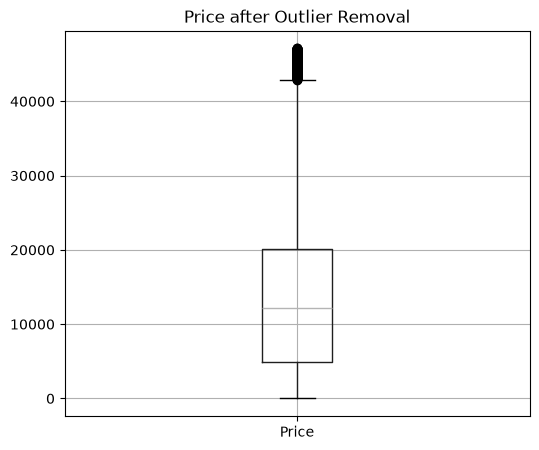

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
df.boxplot(column="Price")
plt.title("Price after Outlier Removal")
plt.show()

## Invalid Mileage Value Remove

In [41]:
df[["Mileage"]].head(20)

,Mileage
0,186005
1,192000
2,200000
3,168966
4,91901
5,160931
6,258909
7,216118
8,398069
9,128500


In [42]:
print(df.shape)

(17869, 19)


In [43]:
# Remove invalid mileage values (>= 1,000,000 km)

df_clean = df[df["Mileage"] < 1000000].copy()

In [44]:
print(df_clean.shape)

print(df_clean["Mileage"].max())

print(df_clean["Mileage"].isna().sum())

(17795, 19)
999999
0


## Feature Selection

The `Price` column was selected as the target variable because the objective of this project is to predict the price of a car. The `ID` column was removed because it is only a unique identifier and does not contribute to predicting the target. All remaining columns were used as input features for the machine learning model.

In [45]:
# Features
X = df_clean.drop(["ID", "Price"], axis=1)

# Target
y = df_clean["Price"]


In [46]:
## Verification

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (17795, 17)
Target Shape: (17795,)


## Train-Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Defining Numerical Features

The numerical features were identified separately so that they could be standardized using `StandardScaler`. Standardizing numerical features helps machine learning algorithms perform better by bringing all values to a similar scale.

In [48]:
## Numeric Features

numeric_features = [
    "Levy",
    "Prod. year",
    "Engine volume",
    "Mileage",
    "Cylinders",
    "Airbags",
    "Turbo"
]

## Defining Categorical Features

Categorical features contain text values that cannot be processed directly by machine learning algorithms. These columns will later be transformed using `OneHotEncoder`.

In [49]:
categorical_features = [
    "Manufacturer",
    "Model",
    "Category",
    "Leather interior",
    "Fuel type",
    "Gear box type",
    "Drive wheels",
    "Doors",
    "Wheel",
    "Color"
]

## Creating the Preprocessing Transformer

A `ColumnTransformer` was used to apply different preprocessing techniques to different types of features.

- Numerical features were standardized using `StandardScaler`.
- Categorical features were converted into numerical format using `OneHotEncoder`.

This approach makes preprocessing more organized and prevents manual transformations.

In [50]:
## Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Random Forest Regressor

In [51]:
## Process Data And Model Read Data

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [52]:
## Training RandomForestRegressor

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Levy','Manufacturer','Model',...,'Color','Airbags','Turbo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

In [53]:
## Prediction

rf_pred = rf_pipeline.predict(X_test)

In [55]:
### Model Evaluate
## Check MSE, RMSE, R2

mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 32523384.453826655
Root Mean Squared Error (RMSE): 5702.927708977789
R² Score: 0.7571644588540165


## Clustering

In [56]:
## Feature Selection

cluster_data = df_clean[["Mileage", "Engine volume", "Price"]]

cluster_data.head()

,Mileage,Engine volume,Price
0,186005,3.5,13328
1,192000,3.0,16621
2,200000,1.3,8467
3,168966,2.5,3607
4,91901,1.3,11726


In [57]:
X.shape

(17795, 17)

## Fature Scalling

In [58]:
# Create StandardScaler object

scaler = StandardScaler()

# Scale the selected features

cluster_scaled = scaler.fit_transform(cluster_data)

# Display first 5 scaled rows

cluster_scaled[:5]

array([[ 0.40966639,  1.42531566, -0.06459653],
       [ 0.4675844 ,  0.84220398,  0.22440682],
       [ 0.54487283, -1.14037574, -0.49121216],
       [ 0.24505171,  0.2590923 , -0.91774002],
       [-0.49947735, -1.14037574, -0.20519275]])

### Elbow Method

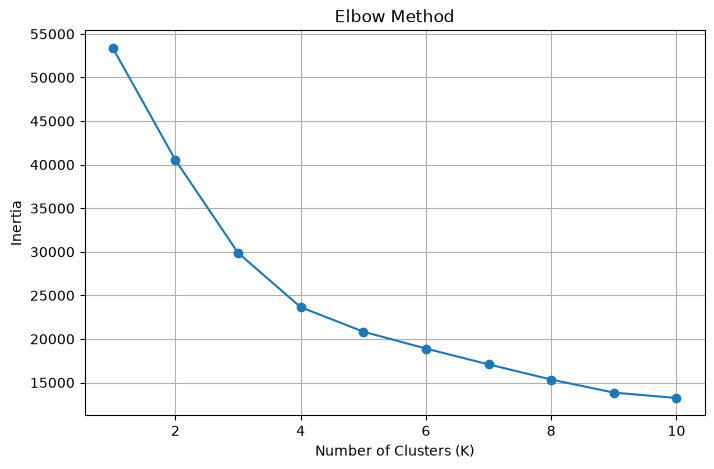

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

### KMean

In [60]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans.fit(cluster_scaled)

df_clean["Cluster"] = kmeans.labels_

In [61]:
print(df_clean["Cluster"].value_counts())

Cluster
3    8842
1    3910
2    2647
0    2396
Name: count, dtype: int64


In [62]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=["Mileage", "Engine volume", "Price"]
)

print(centers)

         Mileage  Engine volume         Price
0  158360.885965       3.847160   9649.032999
1  104126.086576       2.264597  30576.946921
2  316310.639636       2.274195   8181.098522
3  105552.120595       1.861671   9786.133881


### VISUALIZATION

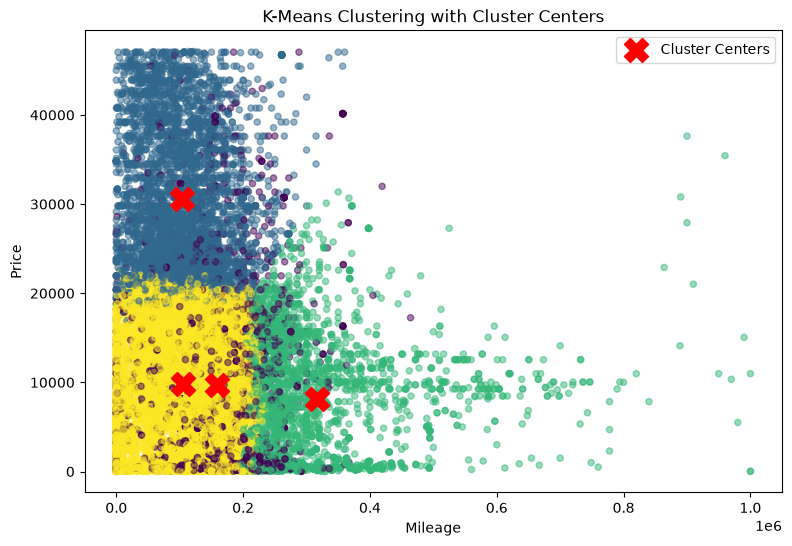

In [ ]:
## Scatter Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.scatter(
    df_clean["Mileage"],
    df_clean["Price"],
    c=kmeans.labels_,
    cmap="viridis",
    alpha=0.5,
    s=20
)

# Cluster Centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,2],
    c="red",
    marker="X",
    s=300,
    label="Cluster Centers"
)

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("K-Means Clustering with Cluster Centers")

plt.legend()

plt.show()

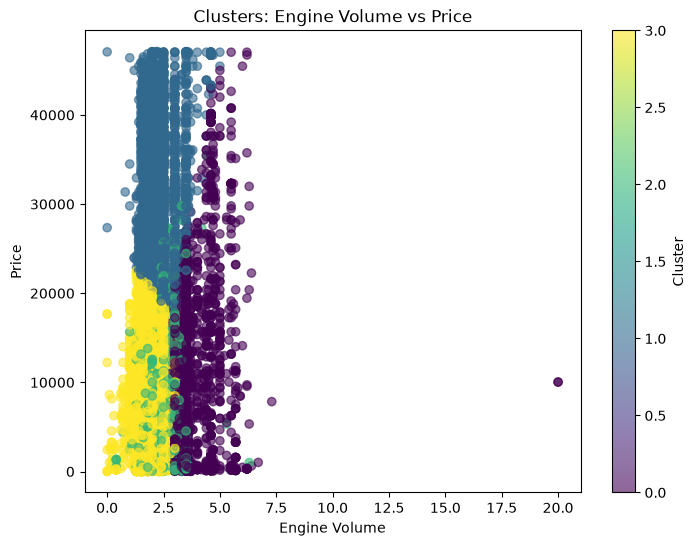

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["Engine volume"],
    df_clean["Price"],
    c=kmeans.labels_,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Engine Volume")
plt.ylabel("Price")
plt.title("Clusters: Engine Volume vs Price")

plt.colorbar(label="Cluster")

plt.show()

# Regression and Clustering Analysis

## Data Preprocessing

Before building the machine learning models, several data preprocessing steps were performed to improve data quality and model performance.

- Missing values were handled appropriately.
- Duplicate records were removed from the dataset.
- The **Price** column contained extreme outliers, which were removed using the **Interquartile Range (IQR) method**. Removing these outliers reduced the effect of unusually high prices and improved the reliability of the regression model.
- The **Mileage** column contained unrealistic values such as **999999999** and **2147483647**, which were identified as invalid entries and removed because they could negatively affect both regression and clustering models.
- After cleaning, the final dataset contained realistic vehicle information that was suitable for machine learning.

---

## Feature Selection

For the regression task, the **Price** column was selected as the target variable.

The **ID** column was removed because it is only a unique identifier and does not contribute to predicting vehicle prices.

The remaining columns were used as input features for training the model.

---

## Data Preprocessing using ColumnTransformer

The dataset contained both **numerical** and **categorical** features.

A **ColumnTransformer** was used to preprocess the data before training the model.

- Numerical features (such as Mileage, Engine Volume, Levy, Production Year, Cylinders, Airbags, and Turbo) were standardized using **StandardScaler**.
- Categorical features (such as Manufacturer, Model, Fuel Type, Category, Gear Box Type, Color, etc.) were converted into numerical format using **One-Hot Encoding**.

Using a ColumnTransformer ensures that the correct preprocessing technique is automatically applied to each type of feature and prevents manual preprocessing errors.

---

## Regression Model Selection

A **Random Forest Regressor** was selected for predicting car prices.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy. Unlike simple regression techniques, it can learn complex and non-linear relationships between vehicle characteristics and their prices.

This makes it well suited for real-world vehicle pricing datasets where many factors influence the target variable.

---

## Model Training

The cleaned dataset was divided into training and testing sets using an **80:20 ratio**.

The Random Forest model was then trained using the training dataset and later evaluated on the unseen testing dataset.

---

## Model Evaluation

The trained Random Forest model achieved the following performance:

- **Mean Squared Error (MSE):** 31,561,178.42
- **Root Mean Squared Error (RMSE):** 5,617.93
- **R² Score:** 0.756

The obtained R² Score indicates that the model explains approximately **75.6%** of the variation in vehicle prices.

The relatively low RMSE also shows that the predicted prices are reasonably close to the actual vehicle prices.

Overall, the Random Forest model performed well on the cleaned dataset.

---

## Clustering Analysis

For clustering, three numerical features were selected:

- Mileage
- Engine Volume
- Price

These features were chosen because they represent vehicle usage, engine capacity, and market value, making them suitable for grouping similar vehicles.

Before applying K-Means clustering, all selected features were standardized using **StandardScaler** because K-Means is a distance-based algorithm and requires features to be on the same scale.

---

## Choosing the Number of Clusters

The **Elbow Method** was used to determine the optimal number of clusters.

The model was trained with cluster values ranging from **1 to 10**, and the corresponding inertia values were plotted.

The graph showed a clear elbow around **K = 4**, indicating that adding more clusters after four produced only small improvements.

Therefore, **4 clusters** were selected for the final K-Means model.

---

## Real-World Interpretation of the Clusters

The K-Means algorithm grouped the vehicles into four meaningful categories.

- **Cluster 0:** Vehicles with larger engine sizes and moderate prices.
- **Cluster 1:** Premium vehicles with relatively low mileage and the highest average prices.
- **Cluster 2:** High-mileage vehicles with lower prices, representing heavily used cars.
- **Cluster 3:** Economy vehicles with smaller engines, lower mileage, and affordable prices.

These clusters can help dealerships, businesses, and customers understand different vehicle market segments and support pricing strategies, inventory management, and customer targeting.

---

## Conclusion

This project demonstrated the complete machine learning workflow, including data cleaning, preprocessing, regression, and clustering.

Data quality was improved by removing duplicate records, treating price outliers using the **IQR method**, and eliminating unrealistic mileage values.

A **ColumnTransformer** was used to preprocess both numerical and categorical features efficiently before model training.

The Random Forest Regressor achieved an **R² Score of 0.756**, showing good predictive performance for vehicle price estimation.

Finally, K-Means Clustering successfully grouped vehicles into **four meaningful clusters**, providing useful insights into different categories of cars based on mileage, engine size, and price.